## Sarcopenia Dataset Analysis

The dataset has undergone preprocessing steps which includes removing unnecessary variables as well as missing data. 

The analysis aims to explore the approach proposed in this paper and identify the relevant features in conditional mean and variance for glucose prediction. 

In [20]:
import sys
sys.path.append("../..")

import math
import numpy as np
import pandas as pd
import sklearn.metrics as skl
from sklearn.model_selection import train_test_split
from knnvs import KnnBag, KnnVar, initialize_knn, roc
import random
import logging
import matplotlib.pyplot as plt

import matplotlib as mpl

mpl.rcParams['axes.labelsize'] = 9

We load the dataset and select the dependent and independent variables we are going to study. We use the same variables for female and male participants. The array `x` will contain the independent variables while `y` the dependent variable.

In [21]:
random.seed(1)
np.random.seed(1)
grida = np.array([5, 10, 20, 50, 100, 200, 500, 1000, 2000])
gridv = np.array([5, 10, 20, 50, 100, 200, 500, 1000, 2000])

df = pd.read_csv('data/sarcopenia.csv')

df = df.loc[df['gender'] == 1]

out = 'tac.x'
inp = np.array(["age", "bmi"])

y = df[out].to_numpy().astype('float32')
x = df[inp].to_numpy().astype('float32')

We initialize a kNN model from the data inputs (`x` and `y`) and two grids (`grida` and `gridv` for conditional mean and variance, respectively) for tunning the k value. The method `initialize_knn` returns an instance of kNN for the conditional mean (`knna0`) and for the conditional variance (`knnv0`), along with the features selected (`fa0` and `fv0`) and the best k (`ka0` and `kv0`) for mean and variance, respectively.

Note: The variables `pva0` and `pvv0` contain the p-values corresponding to each feature in the feature selection process of the conditional mean and variance, respectively.

In [22]:
knna0, fa0, ka0, pva0, knnv0, fv0, kv0, pvv0 = initialize_knn(x, y, grida, gridv, quantile=(1 - 0.01))
knn0 = KnnVar(knna0, knnv0)
print('Selected features for the conditional mean: {}'.format(inp[fa0]))
print('Selected features for the conditional variance: {}'.format(inp[fv0]))

No features passed significance test at quantile=0.99. Using all 2 features.
No features passed significance test at quantile=0.99. Using all 2 features.


Selected features for the conditional mean: ['age' 'bmi']
Selected features for the conditional variance: ['age' 'bmi']


In [23]:
x_mean = np.mean(x, axis=0)

pa = knn0.predict_average(x, k=ka0)
msea = skl.mean_squared_error(y, pa)
pv = knn0.predict_variance(x, k=kv0)
msea = skl.mean_squared_error(y, pv)
grid = np.arange(0, 1, step=0.01)
residuos = np.abs((y - pa) / np.sqrt(pv))
q = np.quantile(residuos, grid)

In [24]:
xk = x[:, 0]
yk = x[:, 1]
xx = np.concatenate((xk.T, yk.T)).reshape(xk.shape[0], 2)
pka = knn0.predict_average(xx, k=ka0)
pkv = knn0.predict_variance(xx, k=kv0)
Z1 = pka - pkv * q[50]  # Extremo inferior del intervalo
Z2 = pka + pkv * q[50]  # Extremo superior del intervalo
dict = {
    "x": xk,
    "y": yk,
    "pka": pka,
    "pkv": pkv,
    "z1": Z1,
    "z2": Z2
}
df2 = pd.DataFrame(dict)
df2.to_csv('sarcopenia_gender_1.csv')

In the following nested loops, we compute the predictions of the conditional mean for the grid `agrig` (age variable) and `bgrid` (bmi variable). We use these variables as `age` and  `bmi` are selected features for the conditional mean and variance. 

In [25]:
x_mean = np.mean(x, axis=0)

agrid = list(np.arange(25, 75, step=0.1))
bgrid = list(np.arange(20, 35, step=0.1))
ages = []
bmis = []
glucoa = []
glucov = []
for a in agrid:
    for b in bgrid:
        xi = np.array([a, b]).reshape((1, 2)).astype('float32')
        glucoa.append(float(knn0.predict_average(xi, k=ka0)))
        glucov.append(float(knn0.predict_variance(xi, k=kv0)))
        ages.append(a)
        bmis.append(b)

dict = {
    "ages": ages,
    "bmis": bmis,
    "glucoa": glucoa,
    "glucov": glucov
}
df2 = pd.DataFrame(dict)
df2.to_csv('sarcopenia_grid_gender_1.csv')

We represent the 3D scatterplot for the total activity count conditional mean. The data reveals a pronounced influence of age on the conditional mean, with bmi exerting a minimal impact.

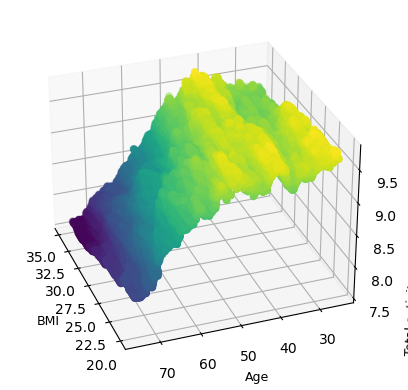

In [26]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df2.bmis, df2.ages, df2.glucoa, c=df2.glucoa, cmap='viridis')
ax.set_xlabel('BMI')
ax.set_ylabel('Age')
ax.set_zlabel('Total activity count conditional mean')
ax.view_init(elev=30, azim=160)  # elevation and azimuth
plt.savefig('sarcopenia_gender_1_avg.png', bbox_inches='tight', pad_inches=0)

We represent the 3D scatterplot for the total activity count conditional standar deviation. Both weight and heart rate proportionally influence the standard deviation, which rises concurrently with them. 

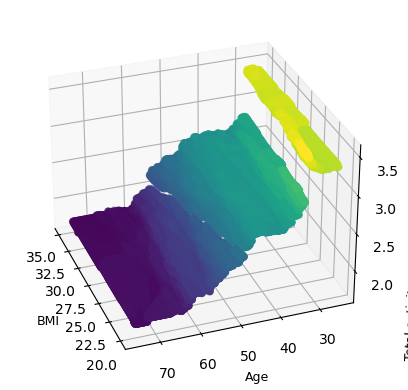

In [27]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
dev = np.sqrt(df2.glucov)
ax.scatter(df2.bmis, df2.ages, dev, c=dev, cmap='viridis')
ax.set_xlabel('BMI')
ax.set_ylabel('Age')
ax.set_zlabel('Total activity count standard deviation')
ax.grid(True)
ax.set_facecolor('white')  # Adjust background color
ax.view_init(elev=30, azim=160)  # elevation and azimuth
plt.savefig('sarcopenia_gender_1_var.png', bbox_inches='tight', pad_inches=0)